In [87]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Go up one level from doomsday/ to habitability/
sys.path.insert(0, str(Path.cwd().parent))
from calculator import SeaIceCalc, Habitability, SST, SRD, Tempdiff, Tempdiffall

Open the file

In [88]:
file = "../../solarflux/stability/run_0.1_5yr/output.nc"
ds = xr.open_dataset(file)
# ds_crop = ds.sel(time=slice("2002-01-01", "2002-12-31"))

Extract habitability for each month

In [89]:
results_hab = []
yearly_data = ds.groupby("time.year")

In [90]:
for year, year_ds in yearly_data:

    hab = {
        "month": None,
        "sm_tot": [],  "sm_nhem": [],  "sm_shem": [],
        "st_tot": [],  "st_nhem": [],  "st_shem": [],
        "tsurf_tot": [], "tsurf_nhem": [], "tsurf_shem": [],
    }

    monthly_data = year_ds.groupby("time.month")
    months = np.array(sorted(monthly_data.groups.keys()), dtype=int)
    hab["month"] = months

    for month, month_ds in monthly_data:

        # Whole globe
        fraction_sm = Habitability.fraction(month_ds, "sm")[0]
        fraction_st = Habitability.fraction(month_ds, "st")[0]
        fraction_tsurf = Habitability.fraction(month_ds, "tsurf")[0]

        hab["sm_tot"].append(fraction_sm)
        hab["st_tot"].append(fraction_st)
        hab["tsurf_tot"].append(fraction_tsurf)
    
        # Northern hemisphere
        sm_n = Habitability.fraction(month_ds, "sm", lat=slice(0,24))[0]
        st_n = Habitability.fraction(month_ds, "st", lat=slice(0,24))[0]
        tsurf_n = Habitability.fraction(month_ds, "tsurf", lat=slice(0,24))[0]

        hab["sm_nhem"].append(sm_n)
        hab["st_nhem"].append(st_n)
        hab["tsurf_nhem"].append(tsurf_n)

        # Southern hemisphere
        sm_s = Habitability.fraction(month_ds, "sm", lat=slice(24,48))[0]
        st_s = Habitability.fraction(month_ds, "st", lat=slice(24,48))[0]
        tsurf_s = Habitability.fraction(month_ds, "tsurf", lat=slice(24,48))[0]

        hab["sm_shem"].append(sm_s)
        hab["st_shem"].append(st_s)
        hab["tsurf_shem"].append(tsurf_s)
    
    # convert lists of scalars to numpy arrays for math/plotting later
    for k, v in list(hab.items()):
        # keep 'month' as-is (already an array)
        if k == "month":
            continue
        # convert lists to numpy arrays
        if isinstance(v, list):
            hab[k] = np.array(v) 
    
    # Store results
    results_hab.append({"year": year, "data": hab})

In [91]:
print(results_hab[0])
print(results_hab[1])

{'year': np.int64(2000), 'data': {'month': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]), 'sm_tot': array([83.06883198, 84.52251576, 85.25536424, 85.6778584 , 85.83069139,
       85.9748089 , 85.99893844, 86.06220621, 86.08992702, 86.15414283,
       86.27272432, 86.33694013]), 'sm_nhem': array([84.43248087, 85.22116904, 85.81580879, 86.28944198, 86.48670364,
       86.57938321, 86.57938321, 86.67941836, 86.7232488 , 86.82478292,
       87.01227673, 87.11381085]), 'sm_shem': array([80.72232102, 83.32030192, 84.2909743 , 84.6254705 , 84.70185247,
       84.93448228, 85.00013293, 85.00013293, 85.00013293, 85.00013293,
       85.00013293, 85.00013293]), 'st_tot': array([68.65172878, 60.79303058, 51.45261554, 37.8148756 , 31.48804705,
       26.12738622, 20.50153375, 17.05299513, 16.10647607, 15.3487054 ,
       14.99984506, 14.90627049]), 'st_nhem': array([61.56353823, 49.60379371, 41.33008011, 29.68196951, 25.55471118,
       20.98623747, 15.57478073, 13.01895351, 12.42253042, 

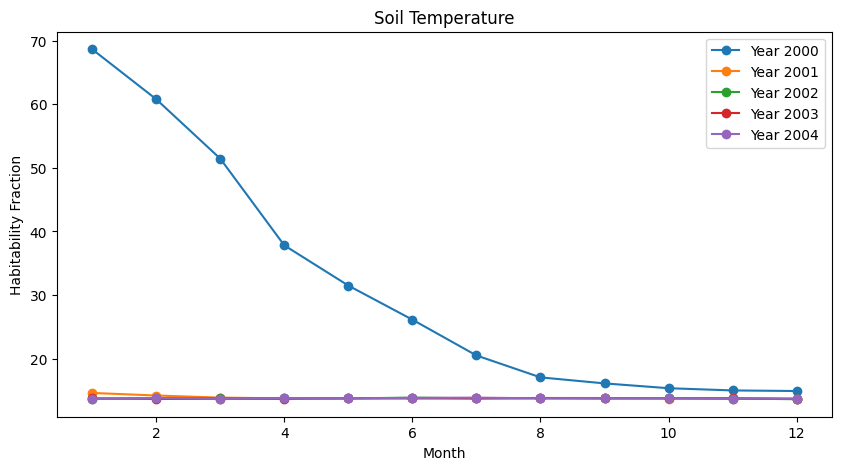

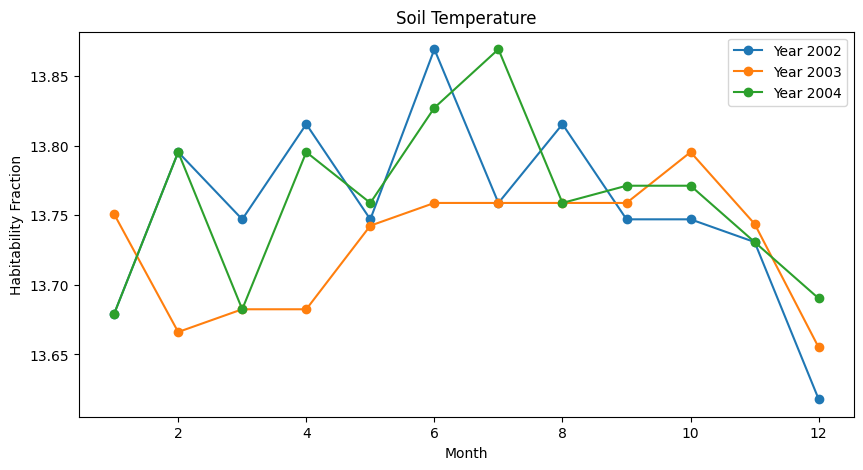

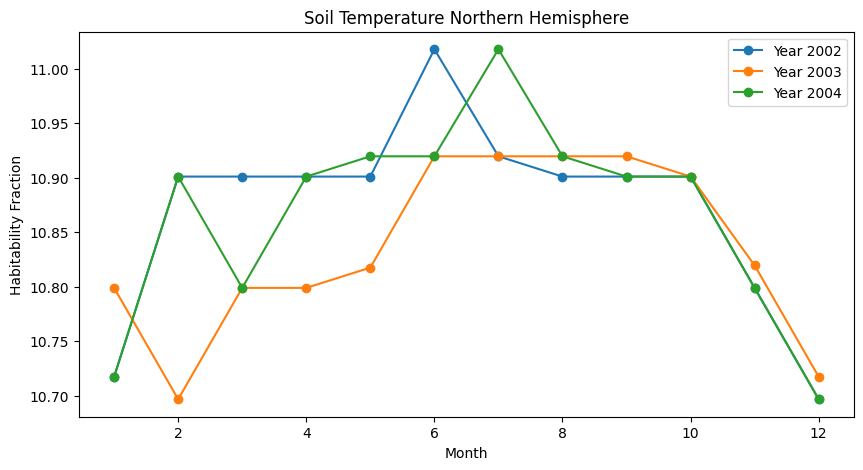

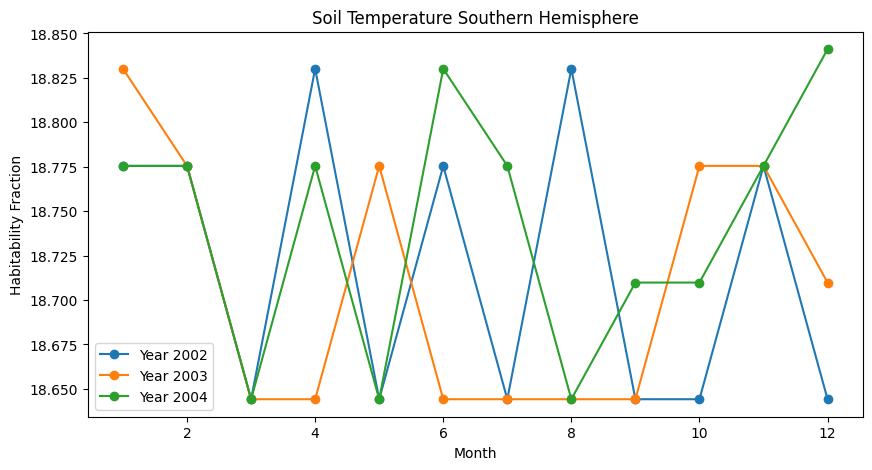

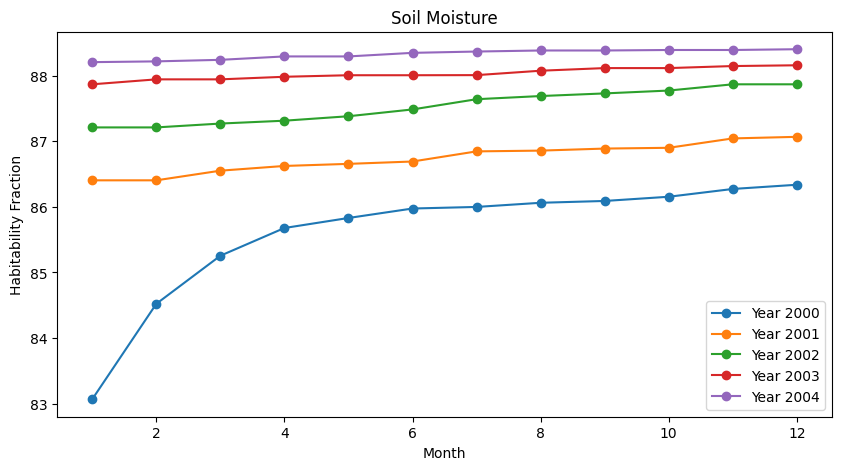

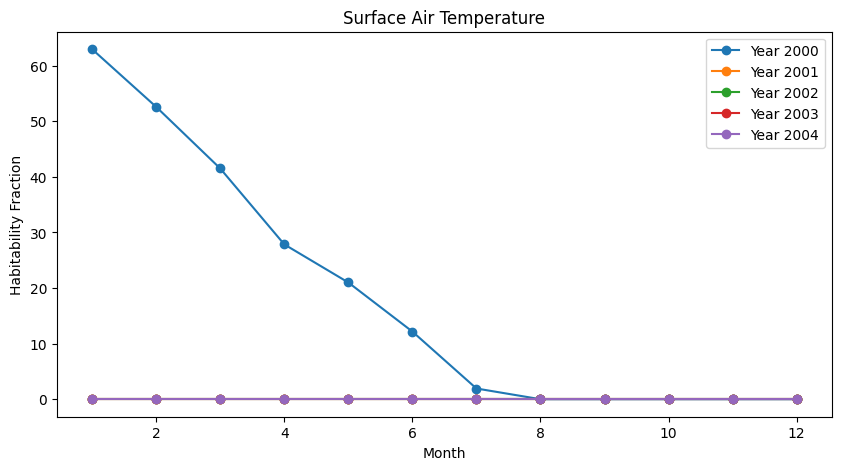

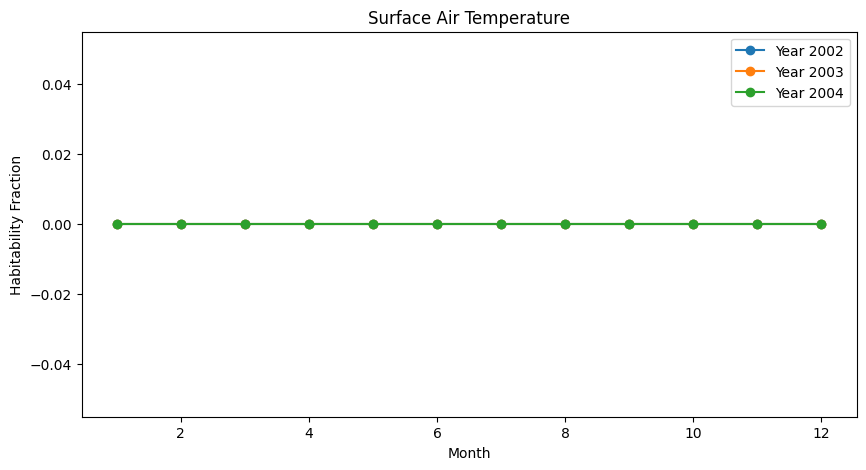

In [92]:
fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    st = yr_dict["data"]["st_tot"]
    plt.plot(month, st, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Soil Temperature")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab[2:]:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    st = yr_dict["data"]["st_tot"]
    plt.plot(month, st, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Soil Temperature")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab[2:]:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    st = yr_dict["data"]["st_nhem"]
    plt.plot(month, st, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Soil Temperature Northern Hemisphere")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab[2:]:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    st = yr_dict["data"]["st_shem"]
    plt.plot(month, st, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Soil Temperature Southern Hemisphere")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    sm = yr_dict["data"]["sm_tot"]
    plt.plot(month, sm, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Soil Moisture")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    tsurf = yr_dict["data"]["tsurf_tot"]
    plt.plot(month, tsurf, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Surface Air Temperature")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab[2:]:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    tsurf = yr_dict["data"]["tsurf_tot"]
    plt.plot(month, tsurf, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Surface Air Temperature")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

We can see habitability stabilises in year 2, so now look at the data over the course of the 3rd year

Make a global plot every 3 months to see what sea ice, sst, precipitation, temperature is doing

In [93]:
ds_crop = ds.sel(time=slice("2002-01-01", "2003-01-01"))
grouped_data = ds_crop.groupby("time.month")

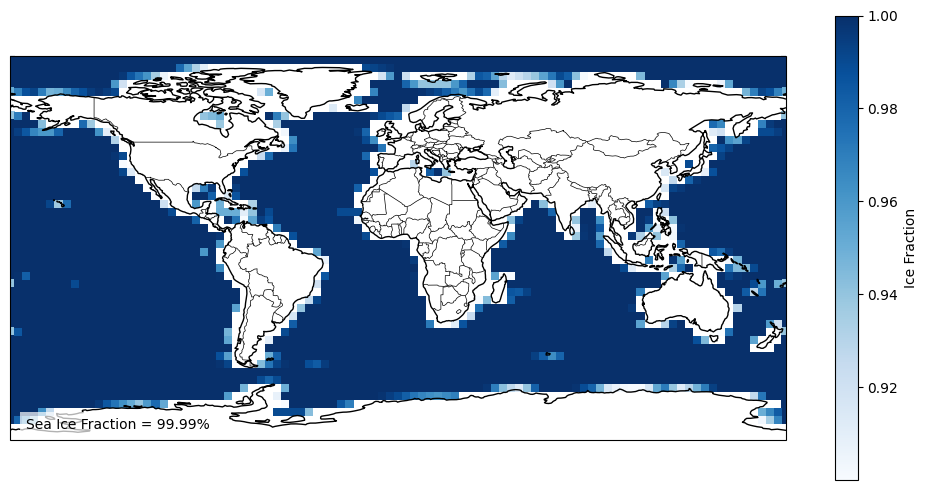

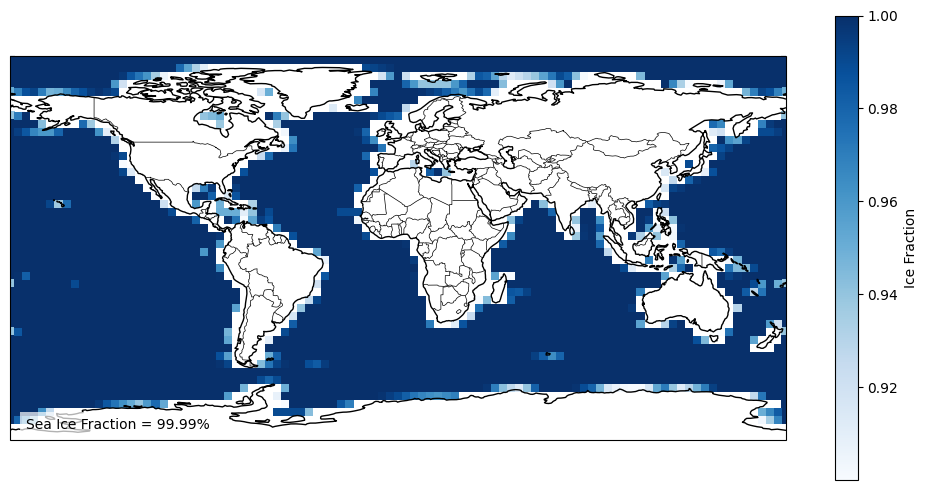

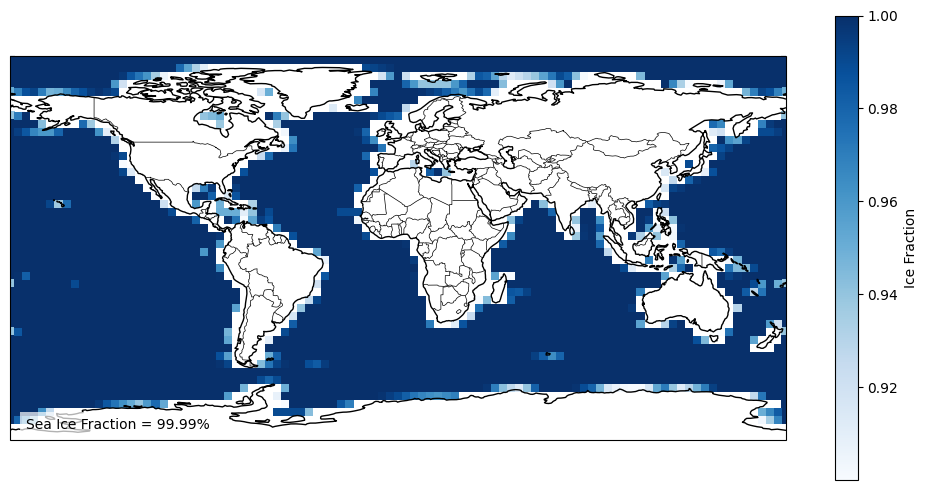

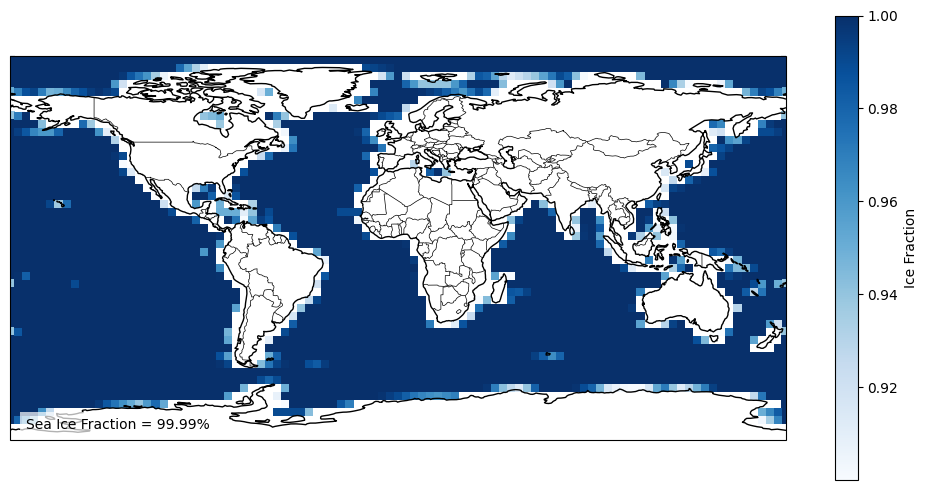

In [101]:
months_to_keep = [3,6,9,12]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        # Ice data
        ice_frac = SeaIceCalc.ice_frac(month_ds)[0]
        ice_dist = SeaIceCalc.ice_frac(month_ds)[1]

        # Land-sea mask
        lsm = month_ds["lsm"]

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        ice_dist.where(lsm<=0.1).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Ice Fraction"},
            cmap="Blues"
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Sea Ice Fraction = {ice_frac:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )
        plt.tight_layout()       

In [ ]:
for month, month_ds in monthly_data:

        # Whole globe
        fraction_sm = Habitability.fraction(month_ds, "sm")[0]
        fraction_st = Habitability.fraction(month_ds, "st")[0]
        fraction_tsurf = Habitability.fraction(month_ds, "tsurf")[0]

        hab["sm_tot"].append(fraction_sm)
        hab["st_tot"].append(fraction_st)
        hab["tsurf_tot"].append(fraction_tsurf)
    
        # Northern hemisphere
        sm_n = Habitability.fraction(month_ds, "sm", lat=slice(0,24))[0]
        st_n = Habitability.fraction(month_ds, "st", lat=slice(0,24))[0]
        tsurf_n = Habitability.fraction(month_ds, "tsurf", lat=slice(0,24))[0]

        hab["sm_nhem"].append(sm_n)
        hab["st_nhem"].append(st_n)
        hab["tsurf_nhem"].append(tsurf_n)

        # Southern hemisphere
        sm_s = Habitability.fraction(month_ds, "sm", lat=slice(24,48))[0]
        st_s = Habitability.fraction(month_ds, "st", lat=slice(24,48))[0]
        tsurf_s = Habitability.fraction(month_ds, "tsurf", lat=slice(24,48))[0]

        hab["sm_shem"].append(sm_s)
        hab["st_shem"].append(st_s)
        hab["tsurf_shem"].append(tsurf_s)
    
    # convert lists of scalars to numpy arrays for math/plotting later
    for k, v in list(hab.items()):
        # keep 'month' as-is (already an array)
        if k == "month":
            continue
        # convert lists to numpy arrays
        if isinstance(v, list):
            hab[k] = np.array(v) 
    
    # Store results
    results_hab.append({"year": year, "data": hab})